# Michigan Drought Analysis

## Abstract
This study focuses on drought conditions in the otherwise humid, continental climate of the state of Michigan, USA. Drought is a concern in this region because the surrounding Great Lakes contain approximately 20% of the Earth's fresh water supply. The aim of this study is to characterize monthly drought conditions over the years 2000-2024 and to model how much of the state's area is in drought monthly, based on precipitation levels, average monthly temperature, lake levels, and the Palmer Drought Severity Index (PDSI). Based on three sources (NOAA's NCEI climate data, NIDIS drought information, and USACE Great Lake water level averages), which have been scaled to a monthly resolution, this study applied k-means clustering (unsupervised analysis) and linear regression (supervised analysis on a temporal split). The key findings in the clustering are that Michigan's monthly climate groups into four interpretable clusters with wet or moderate conditions dominating, but also points of significant drought and drought recovery. Linear regression showed that precipitation and PDSI are the dominant drivers of drought area prediction, but there was poor generalization to new data, especially as Michigan's climate is undergoing active change. Future work should account for climate change and better model time series data.

## Table of Contents
- Introduction
- Methodology
  - Data Sources
  - Data Reshaping, Joining, and Preprocessing
  - Data Splitting
      - Code for the above
  - Exploratory Data Analysis and Visualization
      - Correlation Matrix Discussion and Code
      - Precipitation and Lake Water Levels Discussion and Line Graph
      - Drought Area and Severity Discussion and Line Graph
  - K-Means Clustering
      - Elbow Method
      - Silhouette Score
      - Cluster Visualization
      - K-Means Cluster Discussion
  - Gaussian Generalized Linear Modeling
      - Model Summary, RSME, and $R^2$ scores
      - Gaussian GLM Discussion
- Results
- Limitations
- References

## Introduction
Michigan, USA, is in a humid, continental climactic zone and is surrounded by two of the Great Lakes: Superior to the north of the Upper Peninsula and Michigan-Huron surrounding the "mitten" of the Lower Peninsula. Lake Michigan and Huron are considered one body of water because of their connection at the Straits of Mackinac.[2] Despite being in a humid climate and surrounded by water, Michigan has suffered multiple wide-spread droughts over the last 2000 years.[1] More recently, concerns over climate change have required new metrics to measure drought levels over the Great Lakes specifically.[2][10] Machine learning methods have also shown promising results in categorizing drought globally,[3] using methods such as clustering[5] or focusing on specific locations such as in Ethiopia[4] and Australia[8]. This study compares two machine learning methods: unsupervised clustering and supervised linear regression using data from NOAA's National Centers for Environmental Information, Drought.gov's regularly updated MIDI drought index, and US Army Corps of Engineers (USACE) water level dataset for the Great Lakes. 

## Methodology

### Data Sources

This project draws data from three sources. First, NOAA's National Centers for Environmental Information (NCEI) Statewide-Regional-National Temperature-Precipitation-Drought dataset [6] provided monthly precipitation in inches, average temperature in degrees Fahrenheit, and Palmer Drought Severity Index (PDSI) values ranging between -6 (extreme drought) to 6 (extreme wet period). The PDSI is a meteorological drought index, rather than hydrological, agricultural, or social drought index. 

Second, the National Integrated Drought Information System (NIDIS) Long Term Multi-Indicator Drought Index (MIDI) for Michigan hosted on drought.gov [7] provided a different drought indicator. Drought.gov describes the methodology for producing this dataset as follows: "The U.S. Drought Monitor (2000–present) depicts the location and intensity of drought across the country. Every Thursday, authors from NOAA, USDA, and the National Drought Mitigation Center produce a new map based on their assessments of the best available data and input from local observers. The map uses five categories: Abnormally Dry (D0), showing areas that may be going into or are coming out of drought, and four levels of drought (D1–D4).”[7] Because this drought index began in 2000, this overall analysis in this project is clipped to the period 2000-2024. 

Finally, the US Army Corps of Engineers (USACE) Detroit District Great Lakes Water Management's Coordinated Great Lakes Lake-Wide Average Monthly Mean Water Levels dataset, hosted on Zenodo [9], provides a monthly mean water level in meters for Lake Michigan-Huron, which is a single lake which surrounds the lower peninsula of Michigan, and for Lake Superior, which borders on the upper peninsula of Michigan. Both lakes are needed in this analysis because the climate and drought data is aggregated over the entire state. 

### Data Reshaping, Joining, and Preprocessing
All the data was reshaped into a long format with a common column "date" containing the first day of each month (2000-2024) on which to join the tables. NCEI and USACE data are recorded on a monthly scale, so the weekly NIDIS data was averaged (unweighted) across the weeks that started in a specific month to yield a monthly drought index. Similarly, NCEI's precipitation levels are recorded in inches, but the lake water levels are in meters; thus, the water level data was converted to inches to standardize units across the data. Finally, the drought measures D1-D4 in the NIDIS dataset [7] indicate areas of increasingly severe drought, but they are all summed in D0, which captures the percentage of the territory of Michigan that is in any level of drought. Including D1-D4 as features will cause data leakage between features and response, so they are removed before GLM analysis. They are included in the K-means clustering analysis, with the exception of D4, which contained no data.

The final, merged dataset was checked for NaN or missing values, but had none. 

### Data Splitting

While K-Means analysis requires no data splitting because it is an unsupervised method, the data for the GLM analysis was split along temporal lines. The training set includes measurements from 2000-2019. The test set includes measurements from 2020-2024. The date was later removed from the datasets for both analyses because it did not add any climate or drought information.

See below the code chunks for further analysis and explanation of the methodologies.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Data importing, reshaping, and formatting dates

# USACE Coordinated Great Lakes Lake-Wide Average Monthly Mean Water Levels dataset
lakeMH = pd.read_csv("Monthly_mean_water_levels_Lake_Michigan-Huron_1918-2024.csv", skiprows = 26)
lakeMH["time"] = pd.to_datetime(lakeMH["time"], format="%m/%d/%Y")

lakeS = pd.read_csv("Monthly_mean_water_levels_Lake_Superior_1918-2024.csv", skiprows = 26)
lakeS["time"] = pd.to_datetime(lakeS["time"], format="%m/%d/%Y")

# NCEI Statewide-Regional-National Temperature-Precipitation-Drought dataset
# set up for lack of labels and splitting ID numbers
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
col_names = ["code"] + months
widths = [10, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]

def load_climdiv(path, na_val):
    return pd.read_fwf(path, header=None, widths = widths, 
                        names=col_names, na_values = na_val, dtype={"code": str})

def split_code(df):
    code = df["code"].astype(str)
    df["state"] = code.str[:3]
    df["division"] = code.str[3]
    df["element"] = code.str[4:5]
    df["year"] = code.str[-4:]
    return df 

# precipitation in inches (filter to MI)
precip = split_code(load_climdiv("climdiv-pcpnst-v1.0.0-20260604.txt", na_val = -9.99))
mi_precip = precip[precip["state"] == "020"].copy()

# average temperature in Fahrenheit (filter to MI)
temp = split_code(load_climdiv("climdiv-tmpcst-v1.0.0-20260604.txt", na_val = -99.90))
mi_temp = temp[temp["state"] == "020"].copy()

# Palmer Drought Severity Index (PDSI) (filter to MI)
pdsi = split_code(load_climdiv("climdiv-pdsist-v1.0.0-20260604.txt", na_val = -99.99))
mi_pdsi = pdsi[pdsi["state"] == "020"].copy()

# reshape NCEI data from a wide format to long, monthly format, add a date column, resort by date
def longify(df, name): 
    df = df.melt(
        id_vars = ["year"],
        value_vars = months,
        var_name = "month",
        value_name = name
    )
    df["date"] = pd.to_datetime(df["year"] + "-" + df["month"], format = "%Y-%b")
    df = df.sort_values("date").reset_index(drop=True)
    return df
 
long_precip = longify(mi_precip, name = "precip")
long_temp = longify(mi_temp, name = "temp")
long_pdsi = longify(mi_pdsi, name = "pdsi")

# NIDIS Long Term Multi-Indicator Drought Index (Midi) for Michigan weekly dataset to monthly
drought = pd.read_csv("USDM-michigan.csv")
drought["MapDate"] = pd.to_datetime(drought["MapDate"], format="%Y%m%d")
drought["month"] = drought["MapDate"].dt.to_period("M").dt.to_timestamp()
drought_monthly = drought.groupby("month")[["None", "D0", "D1", "D2", "D3", "D4"]].mean().reset_index()


In [3]:
# Join drought_monthly, long_precip, long_temp, long_pdsi, lakeMH, LakeS on dates

# Clip each file to only the necessary columns, rename date columns to "date"
nidis = drought_monthly.rename(columns={"month":"date"})
precip_s = long_precip[["date", "precip"]]
temp_s = long_temp[["date", "temp"]]
pdsi_s = long_pdsi[["date", "pdsi"]]
lakeMH_s = lakeMH[["time", "monthly_lakewide_average_water_level"]]
lakeMH_s = lakeMH_s.rename(columns={"time": "date"})
lakeMH_s = lakeMH_s.rename(columns={"monthly_lakewide_average_water_level": "MH_water_level"})
lakeS_s = lakeS[["time", "monthly_lakewide_average_water_level"]]
lakeS_s = lakeS_s.rename(columns={"time": "date"})
lakeS_s = lakeS_s.rename(columns={"monthly_lakewide_average_water_level": "S_water_level"})

# Join using inner join to clip to shortest span of time
merged1 = nidis.merge(precip_s, on="date", how="inner")
merged2 = merged1.merge(temp_s, on="date", how="inner")
merged3 = merged2.merge(pdsi_s, on="date", how="inner")
merged4 = merged3.merge(lakeMH_s, on="date", how="inner")
merged = merged4.merge(lakeS_s, on="date", how="inner")

merged.to_csv("merged_drought_data.csv", index=False)


In [4]:
# Data cleaning and preprocessing

df = pd.read_csv("merged_drought_data.csv", parse_dates=["date"])

# convert lake water levels to inches
df["MH_water_level"] = df["MH_water_level"] * 39.3700787402
df["S_water_level"] = df["S_water_level"] * 39.3700787402

# check for missing values
df.isna().sum() # no NaNs found
df.describe() # no remaining -9.99, -99.90, -99.99 indicators

df.head()

,date,None,D0,D1,D2,D3,D4,precip,temp,pdsi,MH_water_level,S_water_level
0,2000-01-01,73.7650,26.2350,12.5150,0.0800,0.0,0.0,1.68,19.3,-2.97,6925.984252,7211.023622
1,2000-02-01,40.5180,59.4820,8.2580,0.7160,0.0,0.0,1.42,26.5,-2.73,6924.015748,7207.874016
2,2000-03-01,43.2025,56.7975,13.3050,2.7275,0.0,0.0,1.62,38.8,-3.17,6925.196850,7207.874016
3,2000-04-01,27.7600,72.2400,44.5525,6.2875,0.0,0.0,2.41,42.4,-2.98,6925.984252,7209.448819
4,2000-05-01,34.0420,65.9580,28.6400,0.0000,0.0,0.0,4.64,56.6,0.73,6929.133858,7211.023622


In [5]:
# Scale and split data for analysis

# prep data for K-means: scale precipitation, temperature, water levels, not drought percentages
# remove date and drought indices before scaling, add back after
# D4 was left off completely because it contained no data
dates_drought = df[["date", "None", "D0", "D1", "D2", "D3"]]
features = df.drop(["date", "None", "D0", "D1", "D2", "D3", "D4"], axis=1)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features) 

df_scaled = pd.DataFrame(features_scaled, columns = features.columns, index=df.index)
df_scaled[["date", "None", "D0", "D1", "D2", "D3"]] = dates_drought
# use df_scaled for the K-Means Cluster analysis

# prep data for GLM
# remove D1-D3 because they are summed into D0; remove None because 100% = None + D0 
df_glm = df_scaled.drop(["D1", "D2", "D3", "None"], axis=1)

# Split into response (y) and predictors (X)
X = df_glm.drop("D0", axis=1)
y = df_glm[["date", "D0"]]

# Choose 2000-2019 for train, 2020-2024 for test to use in GLM
X_train = X[X["date"].dt.year <= 2019]
X_test = X[X["date"].dt.year >= 2020]
y_train = y[y["date"].dt.year <= 2019]
y_test = y[y["date"].dt.year >= 2020]

# remove date from X_train, X_test, y_train, and y_test to prep for the GLM analysis
X_train = X_train.drop("date", axis=1)
X_test = X_test.drop("date", axis=1)
y_train = y_train["D0"]
y_test = y_test["D0"]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((240, 5), (60, 5), (240,), (60,))

## Exploratory Data Analysis and Visualization

### Correlation Matrix Discussion
Below is a correlation matrix on the scaled data where the NIDIS drought area indices [7] were left unscaled because they are percentages of the territory of Michigan that are under drought conditions. The NIDIS index is as follows:
- D4 - Exceptional Drought (0-2 percentile)
- D3 - Extreme Drought (2-5 percentile)
- D2 - Severe Drought (5-10 percentile)
- D1 - Moderate Drought (10-20 percentile)
- D0 - Abnormally Dry (20-30 percentile)

Each level is cumulative, so D0 captures all of the area under any drought conditions. Note that Michigan was not under exceptional drought conditions (D4) at any point during 2000-2024, so this level was dropped from the dataset. D0 is the complement of the category 'None' which records the percentage of area that is not under drought conditions in the NIDIS dataset. The relationship between these variables is captured in the heatmap below, which shows strong positive and negative correlations between the NIDIS features.

The Palmer Drought Severity Index (PDSI), precipitation, average temperature, and water levels of Lake Michigan-Huron and Lake Superior have all been standardized in this dataset, which does not affect the correlation matrix. The matrix shows a high level of correlation between the water levels of the two lakes. The correlation between the date and the lake water level is likely spurious. Date and the water level for Lake Superior will be dropped before K-Means Clustering and the GLM analyses. 

The PDSI shows positive and negative correlation at the magnitude of 0.62 with the NIDIS drought indices "None" and "D0", which reflects that both are different measurements of drought. In the K_Means clustering analysis, which includes all 6 drought measurements as features, this means that drought will have an outsized effect on the Euclidean distance calculation used by the K-Means clustering algorithm. 


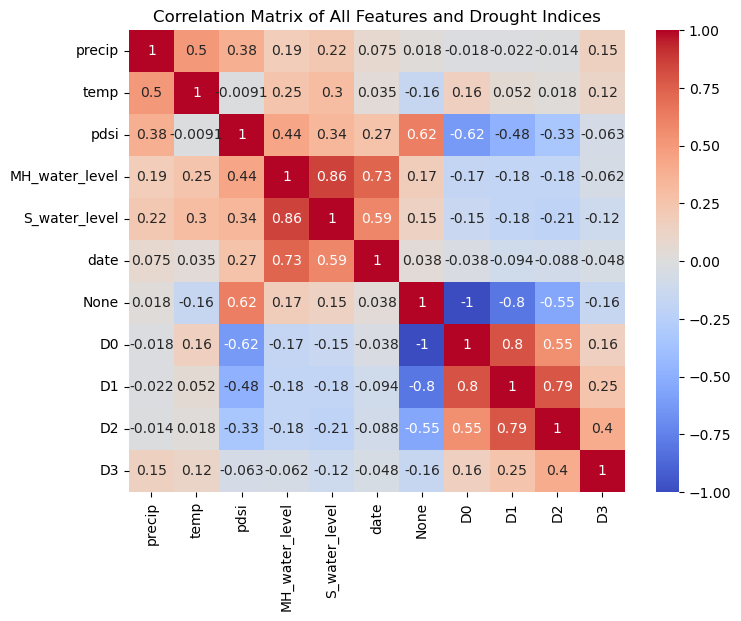

In [6]:
# Correlation matrix for df_scaled
plt.figure(figsize=(8,6))
sns.heatmap(df_scaled.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of All Features and Drought Indices")
plt.show()

### Precipitation and Lake Water Levels Discussion

The line graph below shows the change over time in standardized precipitation amounts and average water levels in Lakes Superior and Michigan-Huron. The graph shows an increase in lake water levels from 2014-2020, which correspond to climate-induced alterations in precipitation, lake evaporation, and basin runoff and which have prompted the development of a new model to predict lake water levels: the Great Lakes-Atmosphere Regional Model (GLARM) system.[10] 

The graph also illustrates the correlation between the water levels of the two lakes, which suggests that removing Lake Superior, which is the northern border of the Upper Peninsula, from the clustering and GLM analysis will lead to better interpretability of the results. 

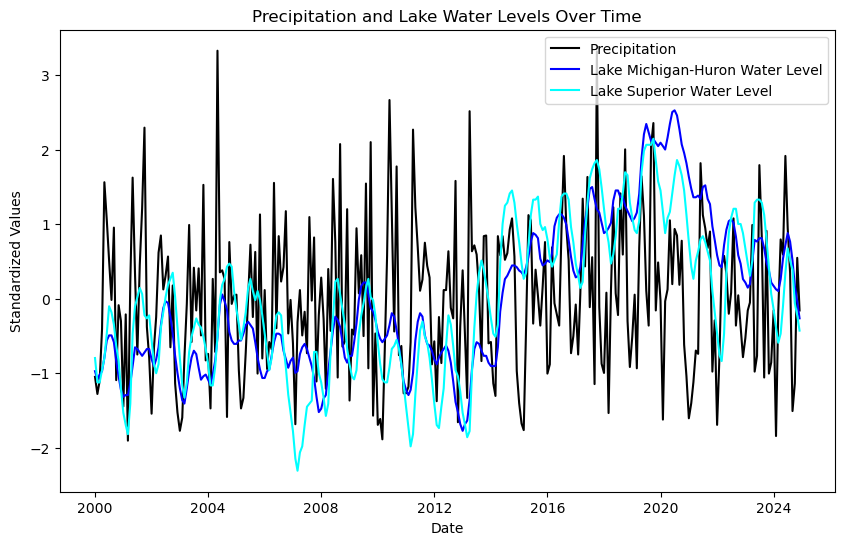

In [7]:
# Line graph of standardized precipitation, lake levels
plt.figure(figsize=(10, 6)) 
plt.plot(df_scaled['date'], df_scaled['precip'], color="black", label="Precipitation")
plt.plot(df_scaled['date'], df_scaled['MH_water_level'], color="blue", label="Lake Michigan-Huron Water Level")
plt.plot(df_scaled['date'], df_scaled['S_water_level'], color="cyan", label="Lake Superior Water Level") 
plt.title('Precipitation and Lake Water Levels Over Time') 
plt.xlabel('Date') 
plt.ylabel('Standardized Values') 
plt.legend()    
plt.show()


### Drought Area and Severity Discussion

Below are two line graphs of the NIDIS Long Term Multi-Indicator Drought Index (MIDI) for Michigan [7] and the Palmer Drought Severity Index (PDSI), both unscaled. The NIDIS MIDI plot shows the percentage of Michigan's territory that is under drought conditions of any sort (D0) over time. See the data section (above) for discussion of the NIDIS drought scale and how the number is derived.

The Palmer Drought Severity Index (PDSI) from the NCEI dataset [6] ranges from 6 to -6 in general, with magnitude 7 levels possible but rare. The PDSI value scale is: 
 - greater than 4.0 = extreme wet period
 - 3.0 to 4.0 = severe wet period
 - 2.0 to 3.0 = moderate wet period
 - 1.0 to 2.0 = mild wet period
 - 0.5 to 1.0 = incipient wet period
 - 0.5 to -.5 = normal
 - -0.5 to -1.0 = incipient drought
 - -1.0 to -2.0 = mild drought
 - -2.0 to -3.0 = moderate drought
 - -3.0 to -4.0 = severe drought
 - less than -4.0 = extreme drought

While the NIDIS data shows the spatial extent of the droughts in Michigan, the PDSI shows a measure of the severity of the drought based on meteorological conditions over time. Thus, in the period between 2017 and 2020, the NIDIS shows several spikes where 20% or 60% of the state of Michigan was under drought conditions, the overall period between 2017 and 2020 was considered a moderate to severe wet period for the state. 

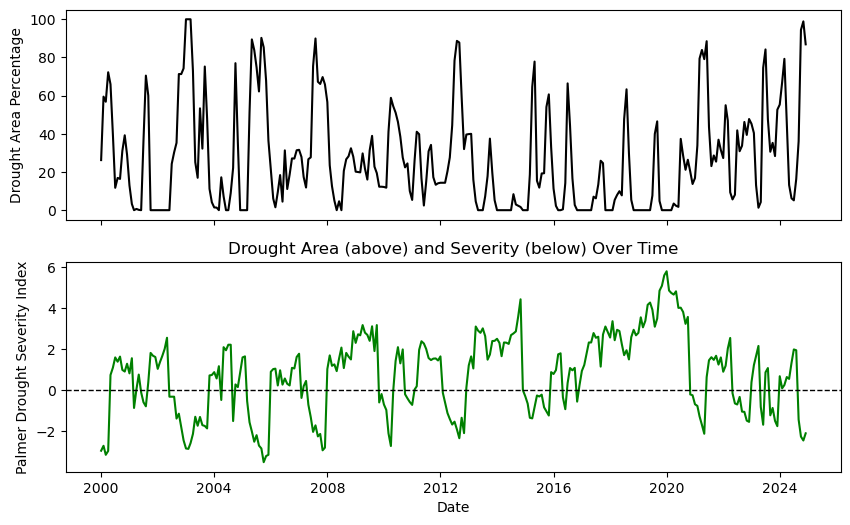

In [8]:
# Drought area and severity over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True) 
plt.title('Drought Area (above) and Severity (below) Over Time') 
ax1.plot(df_scaled['date'], df_scaled['D0'], color = "black")
ax1.set_ylabel("Drought Area Percentage")
ax2.plot(df['date'], df['pdsi'], color="green")
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_ylabel("Palmer Drought Severity Index")
plt.xlabel('Date') 
plt.show()


### K-Means Clustering

The unsupervised method used for this project is K-Means Clustering. As discussed above, the NIDIS drought indicators None, D0, D1, D2, and D3 and the PDSI measurement included might skew clustering toward drought severity. The elbow method of plotting the inertia scores aka the within-cluster sum of squares (WCSS) suggested that 3 clusters were appropriate for our analysis, after which additional clusters offered diminishing returns on cluster coherence. The silhouette scores suggest that 4 clusters, with a score of 0.517, still offer clusters with compactly grouped data points. For this analysis I chose 4 clusters to differentiate more than one cluster between "wet" and "drought". 

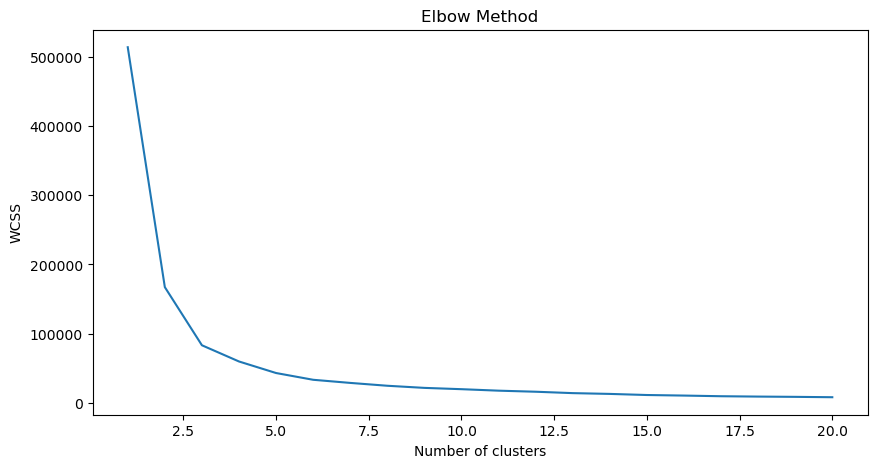

In [9]:
# Unsupervised method: K-Means Cluster Analysis

# Ignore KMeans warnings
import warnings
warnings.filterwarnings("ignore")

# Drop date and Lake Superior water level (per correlation matrix discussion)
df_kmeans = df_scaled.drop(["date", "S_water_level"], axis=1)

# Elbow method to determine appropriate number of clusters
wcss = []
for i in range(1, 21):
    
    kmeans = KMeans(init='k-means++', max_iter=300, n_init=10, random_state=0, n_clusters=i)
    kmeans.fit(df_kmeans)
    
    wcss.append(kmeans.inertia_)
    
# Plotting the elbow plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Elbow plot identifies 3 clusters as the appropriate number

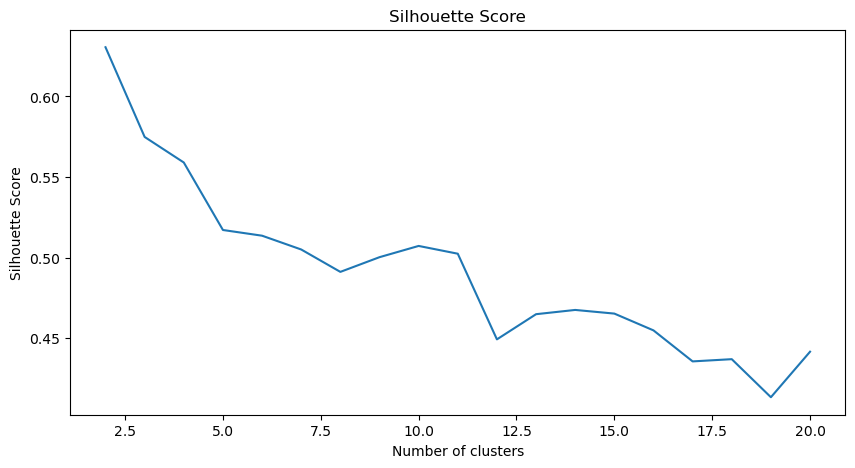

[0.6304842402295702, 0.5748579242212484, 0.5590189672266894, 0.5171683274833556, 0.5136349095920132, 0.5050800694907509, 0.4912008501783231, 0.5003140290037303, 0.5072848820042971, 0.502469061007127, 0.4493612699816716, 0.4649709290289651, 0.46760799442580064, 0.4653429592392753, 0.45493259534242286, 0.43570402834589667, 0.4370814766839201, 0.41349426319563903, 0.44171573536802755]


In [10]:
# Silhouette Score method of evaluating clusters

silhouette_score_list = []
for i in range(2, 21):
    
    kmeans = KMeans(init='k-means++', max_iter=300, n_init=10, random_state=0, n_clusters=i)
    labels = kmeans.fit_predict(df_kmeans)
    silhouette_score_list.append(silhouette_score(df_kmeans, labels))
    
# Plotting the silhouette score
plt.figure(figsize=(10, 5))
plt.plot(range(2, 21), silhouette_score_list)
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

print(silhouette_score_list)

In [11]:
# Visualizing the K-Means Clusters
import plotly.express as px

features = df_kmeans.columns

kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(df_kmeans)

# Adding cluster labels to the dataframe
df_centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
df_centroids['cluster'] = df_centroids.index

fig = px.parallel_coordinates(df_centroids, color='cluster', color_continuous_scale=px.colors.sequential.Viridis)
fig.show()

# extracting cluster size and seasons
print(pd.Series(kmeans.labels_).value_counts().sort_index())

df_scaled['cluster'] = kmeans.labels_
df_scaled['month'] = pd.to_datetime(df_scaled['date']).dt.month
df_scaled.groupby('cluster')['month'].value_counts().sort_index()


0    149
1     43
2     96
3     12
Name: count, dtype: int64


cluster  month
0        1        15
         2        14
         3        17
         4        15
         5        16
         6        18
         7        10
         8         8
         9         6
         10        6
         11       11
         12       13
1        1         2
         2         3
         3         3
         4         4
         5         4
         6         3
         7         5
         8         4
         9         4
         10        6
         11        4
         12        1
2        1         7
         2         7
         3         4
         4         5
         5         4
         6         3
         7        10
         8        12
         9        14
         10       12
         11        9
         12        9
3        1         1
         2         1
         3         1
         4         1
         5         1
         6         1
         8         1
         9         1
         10        1
         11        1
         12        

### K-Means Cluster Discussion

The four clusters produced by the K-Means analysis can be described as follows:

Cluster 3: Significant drought conditions - the NIDIS drought indices are all at a high percentage of Michigan's territory under drought of various levels, and the PDSI is also in the negative range, indicating the severity of the drought conditions. Standardized precipitation, average temperatures, and lake water levels are all below their mean values. 
- There are only 12 out of 300 months in Cluster 3, indicating that significant drought is rare in Michigan.
- The 12 datapoints are evenly distributed throughout the months of the year/ Although the data show no seasonal concentration, there are too few datapoints to rule seasonality out. 

Cluster 0: Significant wet conditions - the NIDIS drought indices are all at low percentages of territory under drought conditions. Precipitation is at its average value, the PDSI is in the positive or "wet" range, and the lake water level is above average. Temperatures are below average levels.
- Wet conditions are the norm for Michigan, with 149 months out of 300 falling into Cluster 0.
- The months between Dec. and June have 13-18 members in Cluster 0. The intermediate months of Nov. and July have 10-11, and the summer and fall months of Aug. to Oct. have only 6 to 8.  

Cluster 1: Possible drought recovery - This intermediate cluster shows high precipitation and high average temperature, but lower than average lake water levels. The PDSI is in the negative or "drought" range, and appx. 70% of Michigan's territory is in a state of drought with 20-25% being in moderate drought conditions, appx. 5% in severe drought, and 0.5% in extreme drought. This cluster might show the datapoints where the state is pulling out of a drought with increased precipitation.
- 43 out of 300 months fall into Cluster 1.
- The datapoints are fairly evenly spaced across months. Jan. and Dec. are low at 1-2 datapoints, Oct. is high at 6 data points, with the remaining months falling between 3-5 points. This suggests that drought recovery happens less often in winter, but most often at the end of the summer and early fall.

Cluster 2: Moderate conditions - for this cluster, the precipitation and lake water level are average and the temperature is slightly above average. The PDSI is around 0, which means neither wet nor drought conditions. Approximately 65% of Michigan's land mass is free from drought conditions, and of the remaining 35%, only appx. 10% is under moderate drought, and less than 5% is under severe drought, with no areas under extreme drought.
- Cluster 2 has 96 months out of 300, the second largest of the clusters.
- The monthly pattern for cluster 2 is complementary to that of Cluster 0, the wet conditions. Aug. to Oct. have the most occurances at 12-14. July, Nov., and Dec. are at 9-10, and Jan. through June have 3-7 with a decreasing trend toward June. The inverse relationship to Cluster 0 suggests that moderate conditions are also a regular state for Michigan, with 245 out of 300 months tending towards either wet or moderate conditions, and drought or recovery from drought occuring in only 55 out of 300 months.

### Gaussian Generalized Linear Modeling

Oyounalsoud *et al.* noted that a GLM based analysis performed well at drought prediction on climate data and soil moisture in an Australian context, and furthermore showed low correlation with the PDSI.[8] Thus, the current study performs a Gaussian GLM analysis of how the NIDIS drought indicator D0 depends on the predictors of Michigan's precipitation level, average temperature, Lake Michigan-Huron water level, and PDSI. The predictors have been scaled, but the response variable has not. As discussed above, the water level for Lake Superior is dropped from the analysis because of its correlation with the water level for Lake Michigan-Huron, to improve interpretability of the coefficients.

In [13]:
# Supervised method: Gaussian General Linear Modelling (GLM)

# Drop Lake Superior water level (per correlation matrix discussion)
X_train = X_train.drop("S_water_level", axis=1)
X_test = X_test.drop("S_water_level", axis=1)

# Add intercept
X_train_c = sm.add_constant(X_train)
X_test_c = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_c).fit()
print(model.summary())

y_pred = model.predict(X_test_c)

rsme = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RSME: {rsme: 0.3f}, Test R^2: {r2: 0.3f}")


                            OLS Regression Results                            
Dep. Variable:                     D0   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     57.88
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           6.05e-34
Time:                        15:26:09   Log-Likelihood:                -1040.8
No. Observations:                 240   AIC:                             2092.
Df Residuals:                     235   BIC:                             2109.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             24.7527      1.273     19.

### Linear Regression Results

Linear regression, with a temporal split into training (2000-2019) and test (2020-2024) sets, showed poor predictive ability. The training $R^2$ was 0.496, which indicates the predictors explain less than half of the variance in the data. The test $R^2$ dropped to 0.136, so the model generalizes poorly to new data. This is likely due to the time-series structure of the data and the fact that Michigan saw a climate-induced wet period from 2014-2020 (as noted above), which straddles the split between the training and test sets. Furthermore, the Durbin-Watson statistic is 0.80, which indicates high positive autocorrelation in the residuals. Again, this is likely due to the temporal nature of the data. Therefore, the GLM analysis did not work as well for the Michigan data as it did for the Australian data. [8]

## Results

Overall, the unsupervised K-Means cluster analysis was more informative than the supervised linear regression on Michigan's drought and climate data. K-Means clustering with 4 clusters identified two groups of typical climate conditions for Michigan: 1) months with significant wet conditions with heavier rain, a "wet" PDSI rating, and high lake water levels, and 2) months with moderate conditions typified by average precipitation and lake water levels with slightly higher temperatures. These two conditions describe 245 out of the 300 months between 2000 and 2024. Only twelve months were predominantly true drought conditions, and 43 months were periods of drought recovery, whether from slight seasonal fluctuations at the end of summer and early fall or more significant drought recovery. 

GLM analysis suggested that average monthly temperature (p-value 0.252) and the water level in Lake Michigan-Huron (p-value 0.941) were not significant factors in explaining the variation in the percentage of Michigan territory under drought conditions. Precipitation amounts were the most significant predictor of drought, unsuprisingly. Overall, the most important take-away from the linear regression analysis is that it is difficult to predict future drought conditions from temporal data when the climate is changing historical patterns of rainfall and drought.  

# Limitations

There are several major limitations to this study:
- First, linear regression does not generalize well on time-series data without additional adjustments, such as the Beluga Whale Optimization (BWO) used by Hameed *et al.* in their study of the Great Lakes water levels.[2] Even with the BWO, Hameed *et al.* settled on the Regularized Extreme Learning Machine (RELM)-BWO as the most succesful method of forecasting droughts in the Great Lakes.
- Second, there is a known climatic event between 2014 and 2020, which included high precipitation and a rise in Great Lake levels in Michigan. This event inspired a new method of modeling lake drought.[10] Thus, the choice to split training and test data for a predictive task during the middle of a known anomaly needs reconsideration for future studies.
- Third, future analysis needs to correct several missteps in the GLM analysis: the data was scaled before being split for GLM analysis, so the values from 2020-2024 were part of the scaling of earlier years. Perhaps, also, the PDSI drought index should be removed from analysis because, as a drought index, it is correlated with the NIDIS drought index. Finally, the fact that D0 is a percentage, and thus bounded, does not fit with the choice of the unbounded model. Logistic regression might be a better choice in future analysis. 

## References
1.	Booth, Robert K., et al. "Widespread Drought Episodes in the Western Great Lakes Region during the Past 2000 Years: Geographic Extent and Potential Mechanisms." *Earth and Planetary Science Letters*, vol. 242, 2006, pp. 415–427.
2.	Hameed, M. M., et al. "Machine Learning Models Development for Accurate Multi-months Ahead Drought Forecasting: Case Study of the Great Lakes, North America." *PLoS ONE*, vol. 18, no. 10, 2023, pp. 1–37, https://doi.org/10.1371/journal.pone.0290891.
3.	Márquez-Grajales, Aldo, et al. "Characterizing Drought Prediction with Deep Learning: A Literature Review." *MethodsX*, vol. 13, 2024, p. 102800, https://doi.org/10.1016/j.mex.2024.102800.
4.	Melese, T., et al. "Machine Learning-Based Drought Prediction Using Palmer Drought Severity Index and TerraClimate Data in Ethiopia." *PLoS ONE*, vol. 20, no. 6, 2025, pp. 1–19, https://doi.org/10.1371/journal.pone.0326174.
5.	Najafi, Ehsan, and Reza Khanbilvardi. "Clustering and Trend Analysis of Global Extreme Droughts from 1900 to 2014." *arXiv*, 2019, https://doi.org/10.48550/arXiv.1901.00052.
6.	National Centers for Environmental Information (NCEI). "Statewide-Regional-National Temperature-Precipitation-Drought Dataset." *NOAA*, https://www.ncei.noaa.gov/pub/data/cirs/climdiv/. Accessed 22 June 2026.
7.	National Integrated Drought Information System (NIDIS). "Long Term Multi-Indicator Drought Index (Midi) for Michigan." *Drought.gov*, https://www.drought.gov/states/michigan. Accessed 22 June 2026.
8.	Oyounalsoud, Mhamd Saifaldeen, et al. "Drought Prediction Using Artificial Intelligence Models Based on Climate Data and Soil Moisture." *Scientific Reports*, vol. 14, 2024, p. 19700, https://doi.org/10.1038/s41598-024-70406-6.
9.	US Army Corps of Engineers (USACE) Detroit District Great Lakes Water Management. "Coordinated Great Lakes Lake-Wide Average Monthly Mean Water Levels." *Zenodo*, Version v2024, 23 Oct. 2025, https://zenodo.org/records/17428224. Accessed 22 June 2026.
10. Xue, P., et al. "Climate projections over the Great Lakes Region: using two-way coupling of a regional climate model with a 3-D lake model," *GMD* vol. 15, no. 11, 2022, pp. 4425-4446.
11. "Python syntax assistance" prompt. *Claude*, version Opus 4.8, Anthropic, 22 June 2026, claude.ai.
12.	"MLA citation formatting assistance" prompt. *Claude*, version Haiku 4.5, Anthropic, 22 June 2026, claude.ai.